# Comprehensive Vector Practice for Machine Learning

This notebook is a collection of vector operations, from fundamentals to typical machine learning applications.

## Learning path
1. Fundamentals and basic operations
2. Vector geometry
3. Linear transformations
4. Numerical operations useful in ML
5. Mini projects: linear regression and classification

Recommendation: run cells in order.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

print('Numpy version:', np.__version__)

Numpy version: 2.0.2


## 1) Create vectors and basic properties

A vector in $\mathbb{R}^n$ is an ordered list of numbers.

In [2]:
v = np.array([2.0, -1.0, 3.0])
w = np.array([0.5, 4.0, -2.0])

print('v =', v)
print('w =', w)
print('Dimension of v:', v.shape[0])
print('Data type:', v.dtype)

v = [ 2. -1.  3.]
w = [ 0.5  4.  -2. ]
Dimension of v: 3
Data type: float64


## 2) Addition, subtraction, and scalar multiplication

Basic operations:
$$
v + w, \quad v - w, \quad \alpha v
$$

In [3]:
alpha = 3.5

print('v + w =', v + w)
print('v - w =', v - w)
print('alpha * v =', alpha * v)
print('Linear combination 2v - 0.5w =', 2 * v - 0.5 * w)

v + w = [2.5 3.  1. ]
v - w = [ 1.5 -5.   5. ]
alpha * v = [ 7.  -3.5 10.5]
Linear combination 2v - 0.5w = [ 3.75 -4.    7.  ]


## 3) Norms and distance

Common norms:
- $L_1$: sum of absolute values
- $L_2$: Euclidean norm
- $L_\infty$: maximum absolute value

In [4]:
l1 = np.linalg.norm(v, ord=1)
l2 = np.linalg.norm(v, ord=2)
linf = np.linalg.norm(v, ord=np.inf)
dist_vw = np.linalg.norm(v - w)

print('||v||_1 =', l1)
print('||v||_2 =', l2)
print('||v||_inf =', linf)
print('dist(v, w) =', dist_vw)

||v||_1 = 6.0
||v||_2 = 3.7416573867739413
||v||_inf = 3.0
dist(v, w) = 7.22841614740048


## 4) Dot product, angle, and cosine similarity

$$
v \cdot w = \sum_i v_i w_i, \quad \cos(\theta) = \frac{v \cdot w}{\|v\|\|w\|}
$$

In [5]:
dot = np.dot(v, w)
cos_sim = dot / (np.linalg.norm(v) * np.linalg.norm(w))
angle_rad = np.arccos(np.clip(cos_sim, -1.0, 1.0))
angle_deg = np.degrees(angle_rad)

print('v · w =', dot)
print('Cosine similarity =', cos_sim)
print('Angle (degrees) =', angle_deg)

v · w = -9.0
Cosine similarity = -0.5345224838248488
Angle (degrees) = 122.31153323742386


## 5) Projection and orthogonal component

Projection of $v$ onto $w$:
$$
\text{proj}_w(v) = \frac{v\cdot w}{w\cdot w} w
$$

In [6]:
proj_v_on_w = (np.dot(v, w) / np.dot(w, w)) * w
orth_component = v - proj_v_on_w

print('Projection of v onto w:', proj_v_on_w)
print('Orthogonal component:', orth_component)
print('Orthogonality check (should be ~0):', np.dot(orth_component, w))

Projection of v onto w: [-0.2222 -1.7778  0.8889]
Orthogonal component: [2.2222 0.7778 2.1111]
Orthogonality check (should be ~0): -8.881784197001252e-16


## 6) Cross product (3D only)

The cross product returns a vector perpendicular to both input vectors.

In [7]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, -1.0, 1.0])
cross_ab = np.cross(a, b)

print('a x b =', cross_ab)
print('a · (a x b) =', np.dot(a, cross_ab))
print('b · (a x b) =', np.dot(b, cross_ab))

a x b = [ 5.  5. -5.]
a · (a x b) = 0.0
b · (a x b) = 0.0


## 7) 2D vector visualization

We visualize vector addition on the plane.

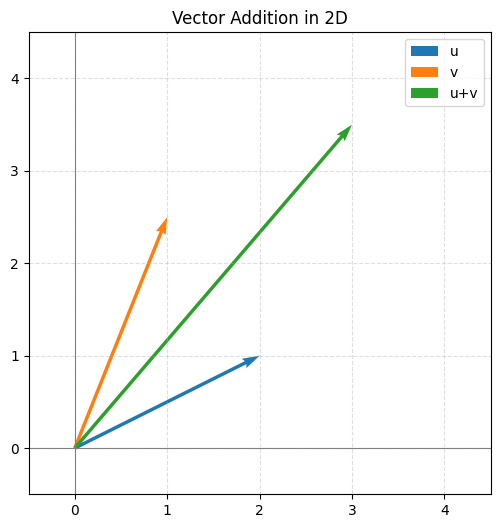

In [8]:
u2 = np.array([2.0, 1.0])
v2 = np.array([1.0, 2.5])
s2 = u2 + v2

plt.figure(figsize=(6, 6))
origin = np.array([0, 0])

for vec, color, label in [(u2, 'tab:blue', 'u'), (v2, 'tab:orange', 'v'), (s2, 'tab:green', 'u+v')]:
    plt.quiver(*origin, *vec, angles='xy', scale_units='xy', scale=1, color=color, label=label)

plt.xlim(-0.5, 4.5)
plt.ylim(-0.5, 4.5)
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Vector Addition in 2D')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

## 8) Matrix-vector product: linear transformations

Example with 2D rotation and scaling.

In [9]:
theta = np.radians(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])
x = np.array([1.0, 2.0])

print('x =', x)
print('R @ x =', R @ x)
print('S @ x =', S @ x)
print('S @ (R @ x) =', S @ (R @ x))

x = [1. 2.]
R @ x = [-0.134   2.2321]
S @ x = [2. 1.]
S @ (R @ x) = [-0.2679  1.116 ]


## 9) Linear combinations, span, and dependence

We inspect matrix rank to estimate linear independence.

In [10]:
B = np.array([[1.0, 2.0, 3.0],
              [2.0, 4.0, 6.0],
              [1.0, 1.0, 1.0]])

rank_B = np.linalg.matrix_rank(B)
print('Matrix B:\n', B)
print('Rank of B =', rank_B)
print('Number of columns =', B.shape[1])
print('Is there linear dependence?', rank_B < B.shape[1])

Matrix B:
 [[1. 2. 3.]
 [2. 4. 6.]
 [1. 1. 1.]]
Rank of B = 2
Number of columns = 3
Is there linear dependence? True


## 10) Distances and similarities in datasets

A very common operation in recommendation, semantic search, and clustering.

In [11]:
X = np.array([
    [1.0, 2.0, 0.0],
    [0.8, 2.2, 0.1],
    [3.0, 0.5, 1.0],
    [2.9, 0.3, 1.2]
])
q = np.array([1.0, 2.1, 0.0])

dists = np.linalg.norm(X - q, axis=1)
cos_sims = (X @ q) / (np.linalg.norm(X, axis=1) * np.linalg.norm(q))

print('L2 distances from q:', dists)
print('Cosine similarity with q:', cos_sims)
print('Closest by distance:', np.argmin(dists))
print('Most similar by cosine:', np.argmax(cos_sims))

L2 distances from q: [0.1    0.2449 2.7495 2.8792]
Cosine similarity with q: [0.9998 0.9945 0.5439 0.4814]
Closest by distance: 0
Most similar by cosine: 0


## 11) Vectorization: loops vs array operations

Vectorization is key for performance in scientific Python.

In [12]:
n = 1_000_000
a_big = np.random.rand(n)
b_big = np.random.rand(n)

%timeit np.dot(a_big, b_big)
%timeit sum(float(a_big[i] * b_big[i]) for i in range(n))

1.04 ms ± 559 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
352 ms ± 11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## 12) Feature standardization

Many models improve when each feature has mean $0$ and standard deviation $1$.

In [13]:
X_raw = np.array([
    [150, 65],
    [160, 70],
    [170, 72],
    [180, 80],
    [190, 90]
], dtype=float)

mu = X_raw.mean(axis=0)
sigma = X_raw.std(axis=0, ddof=0)
X_std = (X_raw - mu) / sigma

print('Original mean:', mu)
print('Original std:', sigma)
print('Standardized mean (~0):', X_std.mean(axis=0))
print('Standardized std (~1):', X_std.std(axis=0))

Original mean: [170.   75.4]
Original std: [14.1421  8.7544]
Standardized mean (~0): [ 0. -0.]
Standardized std (~1): [1. 1.]


## 13) ML Application 1: Linear regression with gradient descent

Model:
$$
\hat{y} = Xw + b
$$
Gradients:
$$
\nabla_w = \frac{1}{m}X^T(\hat{y} - y), \quad \nabla_b = \frac{1}{m}\sum(\hat{y}-y)
$$

In [14]:
rng = np.random.default_rng(42)
m = 200
X = rng.normal(size=(m, 2))
w_true = np.array([2.5, -1.3])
b_true = 0.7
noise = rng.normal(scale=0.4, size=m)
y = X @ w_true + b_true + noise

w = np.zeros(2)
b = 0.0
lr = 0.1
epochs = 300
loss_history = []

for _ in range(epochs):
    y_hat = X @ w + b
    err = y_hat - y
    loss = 0.5 * np.mean(err ** 2)

    grad_w = (X.T @ err) / m
    grad_b = np.mean(err)

    w -= lr * grad_w
    b -= lr * grad_b
    loss_history.append(loss)

print('learned w:', w)
print('learned b:', b)
print('true w:', w_true)
print('true b:', b_true)

learned w: [ 2.4929 -1.3213]
learned b: 0.672216901842755
true w: [ 2.5 -1.3]
true b: 0.7


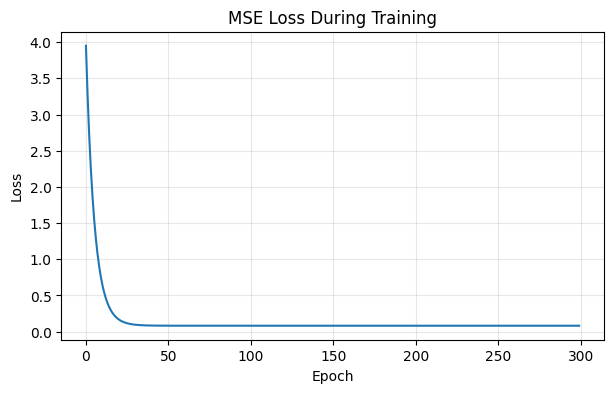

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title('MSE Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

## 14) ML Application 2: Binary classification with dot product

The simplest linear rule uses:
$$
\hat{y} = \mathbb{1}[w^Tx + b > 0]
$$

In [16]:
w_clf = np.array([1.2, -0.8])
b_clf = -0.1

X_test = np.array([
    [2.0, 1.0],
    [0.4, 1.5],
    [1.0, 0.2],
    [0.1, 0.9]
], dtype=float)

scores = X_test @ w_clf + b_clf
pred = (scores > 0).astype(int)

print('Scores:', scores)
print('Predictions:', pred)

Scores: [ 1.5  -0.82  0.94 -0.7 ]
Predictions: [1 0 1 0]


## 15) Bonus: PCA with SVD decomposition

PCA finds directions of maximum variance, based on eigen/singular vectors.

In [17]:
X_pca = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
], dtype=float)

X_centered = X_pca - X_pca.mean(axis=0)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
pc1 = Vt[0]

print('First principal component:', pc1)
print('Approx explained variance PC1:', (S[0]**2) / np.sum(S**2))

First principal component: [-0.6779 -0.7352]
Approx explained variance PC1: 0.963181314348646
